In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,LabelEncoder,OneHotEncoder

In [2]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [3]:
df.shape

(1436, 11)

In [4]:
df.size

15796

In [5]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [8]:
df.describe(include="all")

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Petrol,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,10730.824513,55.947075,68533.259749,NaN,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,NaN,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,NaN,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,NaN,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,NaN,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,NaN,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000


## remove duplicates

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

## missing values

In [12]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

## remove outliers

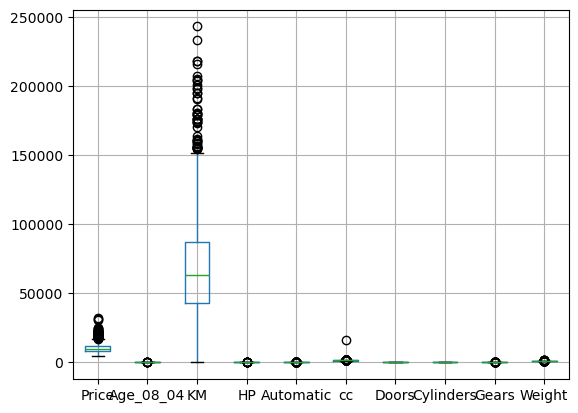

In [13]:
df.boxplot()
plt.show()

In [14]:
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    upper_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

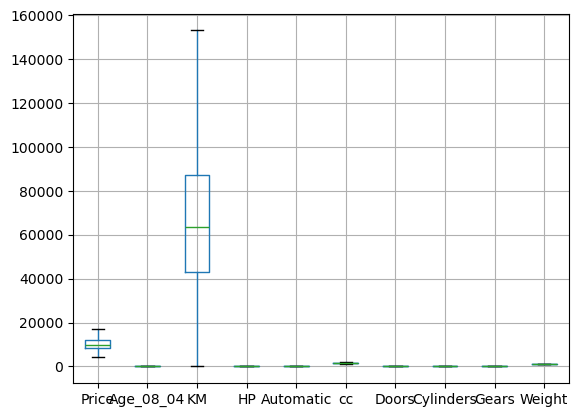

In [15]:
df.boxplot()
plt.show()

## histogram

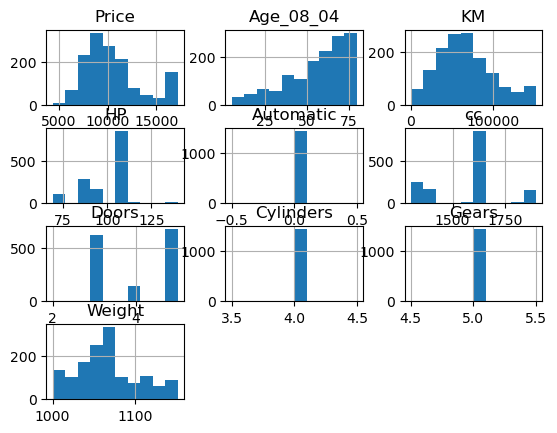

In [16]:
df.hist()
plt.show()

## correlation

In [17]:
df=pd.get_dummies(df,columns=['Fuel_Type'],drop_first=True)
df

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500.0,69.0,20544.0,86.0,0.0,1300.0,3,4,5.0,1025.0,False,True
1432,10845.0,72.0,19000.0,86.0,0.0,1300.0,3,4,5.0,1015.0,False,True
1433,8500.0,71.0,17016.0,86.0,0.0,1300.0,3,4,5.0,1015.0,False,True
1434,7250.0,70.0,16916.0,86.0,0.0,1300.0,3,4,5.0,1015.0,False,True


In [18]:
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False


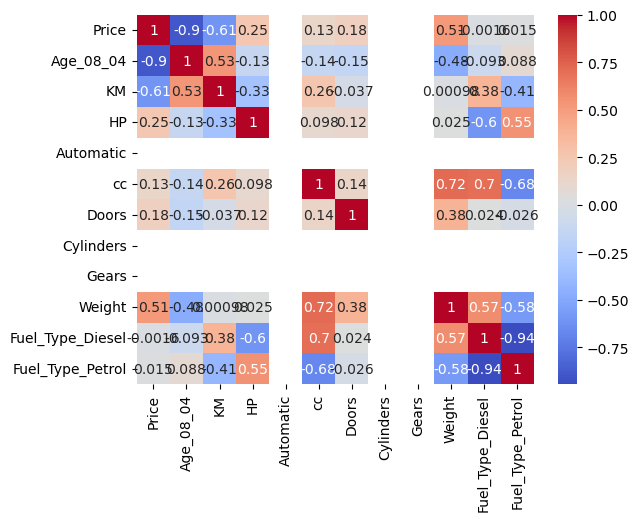

<Figure size 1000x1000 with 0 Axes>

In [19]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()
plt.figure(figsize=(10,10))

## target and features

In [20]:
target=df['Price'] ## dependent  - yaxis
features=df.drop(columns=['Price']) ## independent - xaxis

In [21]:
features.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
1,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
2,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
3,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False
4,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,True,False


## train test split data

In [22]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(287, 11)
(1148, 11)
(287,)
(1148,)


## standardization

In [23]:
std_sca=StandardScaler()          ## scaling method
x_train1=std_sca.fit_transform(x_train)
x_test1=std_sca.transform(x_test)
print('x_train:',x_train1)
print('x_test:',x_test1)

x_train: [[ 0.44302095  1.11880777  0.66384188 ... -0.04559706 -0.35424595
   0.372678  ]
 [ 1.17246102  0.62827985 -1.06099511 ... -0.82921128 -0.35424595
   0.372678  ]
 [-0.00586524 -1.13184974  0.66384188 ...  0.21560768 -0.35424595
   0.372678  ]
 ...
 [ 1.22857179 -0.04980286  0.66384188 ... -0.82921128 -0.35424595
   0.372678  ]
 [ 0.38691018 -0.24803385  0.66384188 ...  0.08500531 -0.35424595
   0.372678  ]
 [ 0.94801792  1.0478255   0.66384188 ...  0.47681241 -0.35424595
   0.372678  ]]
x_test: [[ 0.05024554  0.20786857  0.66384188 ... -0.04559706 -0.35424595
   0.372678  ]
 [ 0.21857786 -0.24321513  0.66384188 ...  0.21560768 -0.35424595
   0.372678  ]
 [ 0.05024554  1.63819028 -2.06715003 ...  1.78283611  2.82289745
  -2.68328157]
 ...
 [-1.57696691 -1.13184974  2.81988812 ...  2.23994441 -0.35424595
   0.372678  ]
 [ 0.94801792  2.21528195 -2.06715003 ...  1.78283611  2.82289745
  -2.68328157]
 [-0.17419756 -0.827809   -0.27044482 ... -1.09041602 -0.35424595
   0.372678  ]]

## linear regression

In [24]:
lin_mod1=LinearRegression()
lin_mod1.fit(x_train1,y_train)
y_train_pred1=lin_mod1.predict(x_train1)
y_test_pred1=lin_mod1.predict(x_test1)

## model1 training

In [25]:
print("MSE:",mean_squared_error(y_train,y_train_pred1))
print("MAE:",mean_absolute_error(y_train,y_train_pred1))
print("RMSE:",np.sqrt(mean_squared_error(y_train,y_train_pred1)))
print("R2_SCORE:",r2_score(y_train,y_train_pred1))

MSE: 1155101.9945475329
MAE: 803.2402969864681
RMSE: 1074.7567141207041
R2_SCORE: 0.8629200272289232


## model1 testing

In [26]:
print("MSE:",mean_squared_error(y_test,y_test_pred1))
print("MAE:",mean_absolute_error(y_test,y_test_pred1))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_test_pred1)))
print("R2_SCORE:",r2_score(y_test,y_test_pred1))

MSE: 1284076.5597017435
MAE: 860.617341041982
RMSE: 1133.1710196178437
R2_SCORE: 0.8559705049575632


In [27]:
pd.DataFrame({'coefficients':lin_mod1.coef_})

,coefficients
0,-1.998206e+03
1,-4.277962e+02
2,3.761194e+02
3,-1.705303e-13
4,-4.134465e+02
5,-7.906275e+01
6,7.105427e-14
7,0.000000e+00
8,8.898595e+02
9,1.160178e+02


## training evaluation

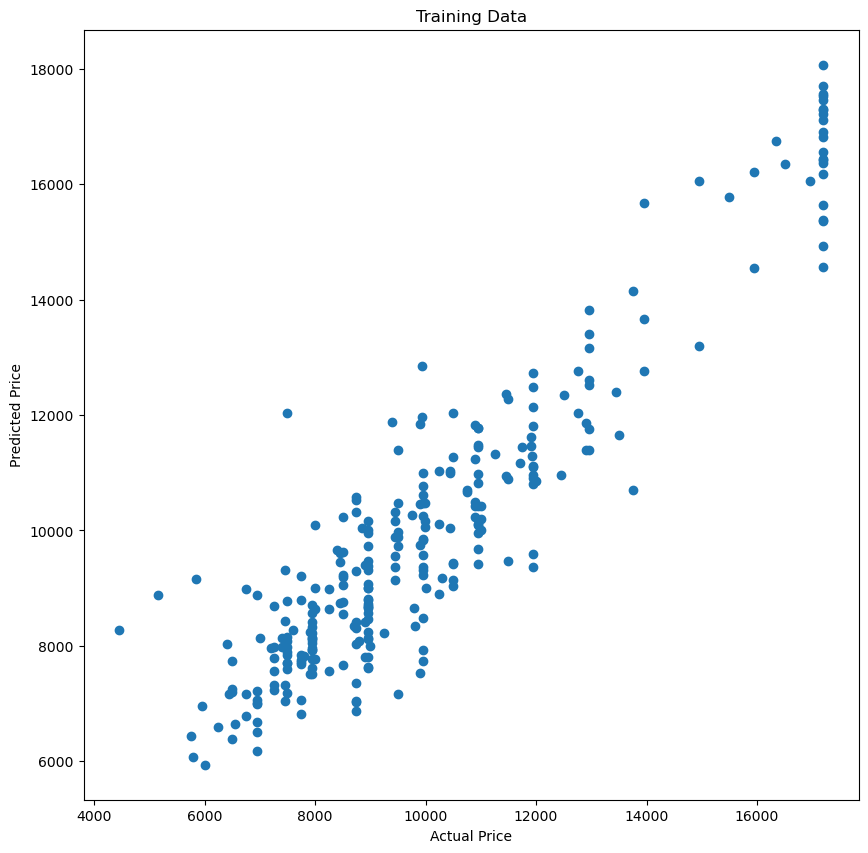

<Figure size 800x500 with 0 Axes>

In [28]:
plt.scatter(y_train, y_train_pred1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Training Data")
plt.show()
plt.figure(figsize=(8,5))

## testing evaluation

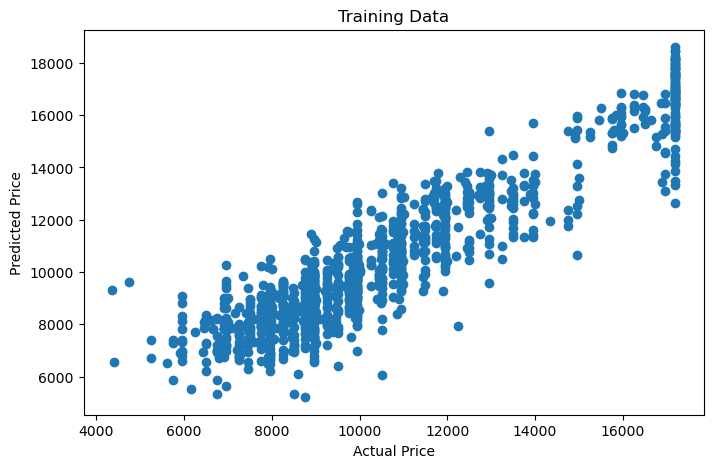

<Figure size 800x500 with 0 Axes>

In [29]:
plt.scatter(y_test, y_test_pred1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Training Data")
plt.show()
plt.figure(figsize=(8,5))

## lasso model

In [30]:
las_mod1=Lasso(alpha=1,max_iter=1000)
las_mod1.fit(x_train1,y_train)
y_train_pred2=las_mod1.predict(x_train1)
y_test_pred2=las_mod1.predict(x_test1)

## model training

In [31]:
print("MSE:",mean_squared_error(y_train,y_train_pred2))
print("MAE:",mean_absolute_error(y_train,y_train_pred2))
print("RMSE:",np.sqrt(mean_squared_error(y_train,y_train_pred2)))
print("R2_SCORE:",r2_score(y_train,y_train_pred2))

MSE: 1155299.4402063715
MAE: 804.516648222596
RMSE: 1074.8485661740315
R2_SCORE: 0.8628965956655937


## model testing

In [32]:
print("MSE:",mean_squared_error(y_test,y_test_pred2))
print("MAE:",mean_absolute_error(y_test,y_test_pred2))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_test_pred2)))
print("R2_SCORE:",r2_score(y_test,y_test_pred2))

MSE: 1286315.331441987
MAE: 860.8818419591103
RMSE: 1134.1584243138113
R2_SCORE: 0.8557193912986258


In [33]:
pd.DataFrame({'coefficients':las_mod1.coef_})

,coefficients
0,-2002.210694
1,-429.993799
2,330.486889
3,0.000000
4,-363.772168
5,-79.066856
6,0.000000
7,0.000000
8,887.025245
9,34.415755


## ridge model

In [34]:
rid_mod1=Ridge(alpha=1,max_iter=1000)
rid_mod1.fit(x_train1,y_train)
y_train_pred3=rid_mod1.predict(x_train1)
y_test_pred3=rid_mod1.predict(x_test1)

## model training

In [35]:
print("MSE:",mean_squared_error(y_train,y_train_pred3))
print("MAE:",mean_absolute_error(y_train,y_train_pred3))
print("RMSE:",np.sqrt(mean_squared_error(y_train,y_train_pred3)))
print("R2_SCORE:",r2_score(y_train,y_train_pred3))

MSE: 1155265.8426197679
MAE: 803.9082934404521
RMSE: 1074.8329370743008
R2_SCORE: 0.8629005828080959


## model testing

In [36]:
print("MSE:",mean_squared_error(y_test,y_test_pred3))
print("MAE:",mean_absolute_error(y_test,y_test_pred3))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_test_pred3)))
print("R2_SCORE:",r2_score(y_test,y_test_pred3))

MSE: 1284362.054253408
MAE: 860.3078664414195
RMSE: 1133.29698413673
R2_SCORE: 0.8559384822282308


In [37]:
pd.DataFrame({'coefficients':rid_mod1.coef_})

,coefficients
0,-1993.013422
1,-433.662893
2,346.952236
3,0.000000
4,-378.502952
5,-77.935568
6,0.000000
7,0.000000
8,884.888791
9,60.824004


## Interpretation of Coefficients

## Interview Questions